In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("customer_shopping_behavior.csv")

In [4]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [7]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(
    lambda x: x.fillna(x.median())
)

In [8]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [9]:
df_ml = df.copy()

In [10]:
df_ml = df_ml.drop("Customer ID", axis=1)

In [11]:
df_ml.columns

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Shipping Type', 'Discount Applied',
       'Promo Code Used', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = df_ml.select_dtypes(include="object").columns

for column in categorical_columns:
    df_ml[column] = label_encoder.fit_transform(df_ml[column])

df_ml.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,55,1,2,1,53,16,0,7,3,3.1,1,1,1,1,14,5,3
1,19,1,23,1,64,18,0,12,3,3.1,1,1,1,1,2,1,3
2,50,1,11,1,73,20,2,12,1,3.1,1,2,1,1,23,2,6
3,21,1,14,2,90,38,1,12,1,3.5,1,3,1,1,49,4,6
4,45,1,2,1,49,36,1,21,1,2.7,1,2,1,1,31,4,0


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_ml)

scaled_data

array([[ 0.71891344,  0.68599434, -1.39414439, ..., -0.78583067,
         1.47163613,  0.01257477],
       [-1.64862924,  0.68599434,  1.5232358 , ..., -1.61655226,
        -0.89463099,  0.01257477],
       [ 0.39008807,  0.68599434, -0.1438386 , ..., -0.16278948,
        -0.30306421,  1.51384863],
       ...,
       [ 0.12702777, -1.45773797, -1.53306726, ..., -0.09356268,
         1.47163613,  1.01342401],
       [-0.00450238, -1.45773797,  0.6896986 , ..., -0.09356268,
         1.47163613,  1.51384863],
       [ 0.52161822, -1.45773797, -0.69953006, ...,  0.52947851,
         1.47163613,  1.01342401]])

In [14]:
from sklearn.cluster import KMeans


In [15]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

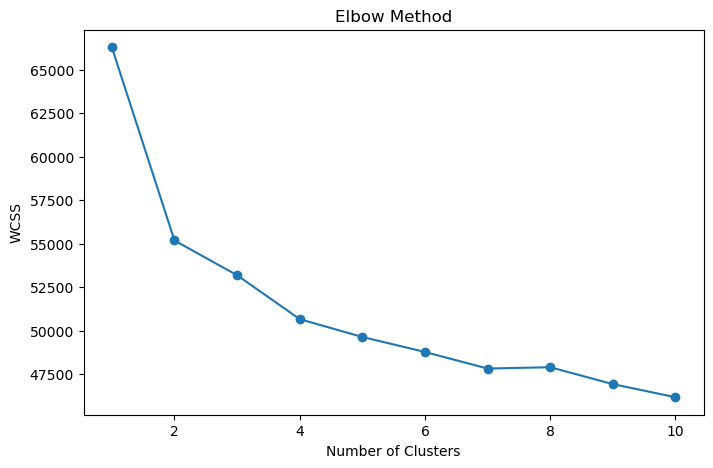

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

clusters

array([2, 2, 2, ..., 1, 1, 1])

In [18]:
df["Cluster"] = clusters

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Cluster
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,2
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,2
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,2
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,2
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,2


In [19]:
df["Cluster"].value_counts()

Cluster
1    1248
2    1053
3     975
0     624
Name: count, dtype: int64

In [20]:
df.groupby("Cluster")[["Age", "Purchase Amount (USD)", "Review Rating", "Previous Purchases"]].mean()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Cluster,,,,
0,44.000000,58.919872,3.727083,25.166667
1,44.007212,60.249199,3.741426,24.596154
2,44.230769,59.491928,3.747483,26.084520
3,44.015385,59.978462,3.778564,25.645128


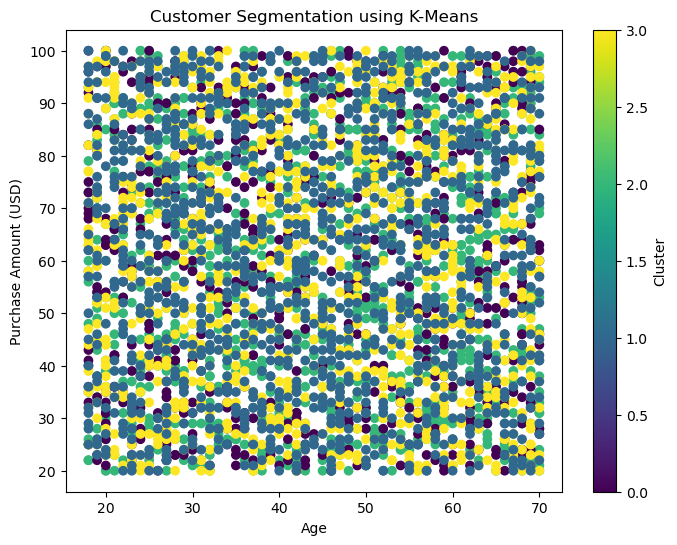

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Age"],
    df["Purchase Amount (USD)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")
plt.title("Customer Segmentation using K-Means")

plt.colorbar(label="Cluster")

plt.show()

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

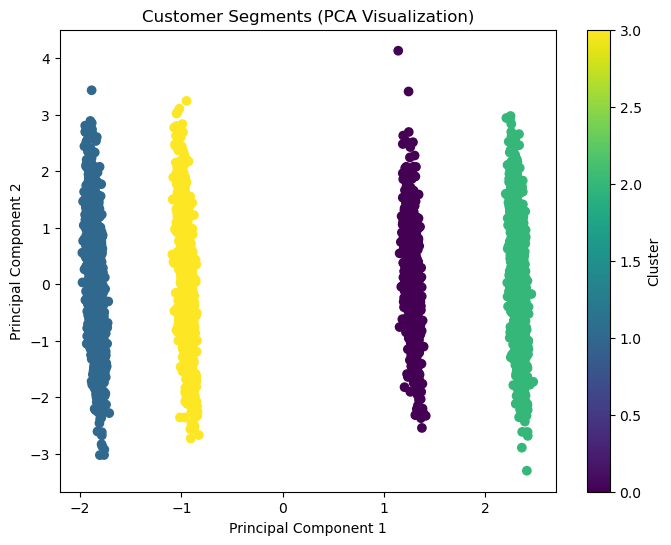

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [24]:
df.groupby("Cluster").agg({
    "Purchase Amount (USD)": ["mean", "min", "max"],
    "Age": ["mean", "min", "max"],
    "Previous Purchases": ["mean", "min", "max"],
    "Review Rating": ["mean"],
    "Subscription Status": lambda x: x.mode()[0],
    "Category": lambda x: x.mode()[0]
})

Purchase Amount (USD)                 Age         Previous Purchases  \
                         mean min  max       mean min max               mean   
Cluster                                                                        
0                   58.919872  20  100  44.000000  18  70          25.166667   
1                   60.249199  20  100  44.007212  18  70          24.596154   
2                   59.491928  20  100  44.230769  18  70          26.084520   
3                   59.978462  20  100  44.015385  18  70          25.645128   

                Review Rating Subscription Status  Category  
        min max          mean            <lambda>  <lambda>  
Cluster                                                      
0         1  50      3.727083                  No  Clothing  
1         1  50      3.741426                  No  Clothing  
2         1  50      3.747483                 Yes  Clothing  
3         1  50      3.778564                  No  Clothing

In [25]:
# -------------------------------
# Model 2: Behavioral Clustering
# -------------------------------

features = df[[
    "Age",
    "Purchase Amount (USD)",
    "Previous Purchases",
    "Review Rating"
]]

features.head()

,Age,Purchase Amount (USD),Previous Purchases,Review Rating
0,55,53,14,3.1
1,19,64,2,3.1
2,50,73,23,3.1
3,21,90,49,3.5
4,45,49,31,2.7


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [27]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

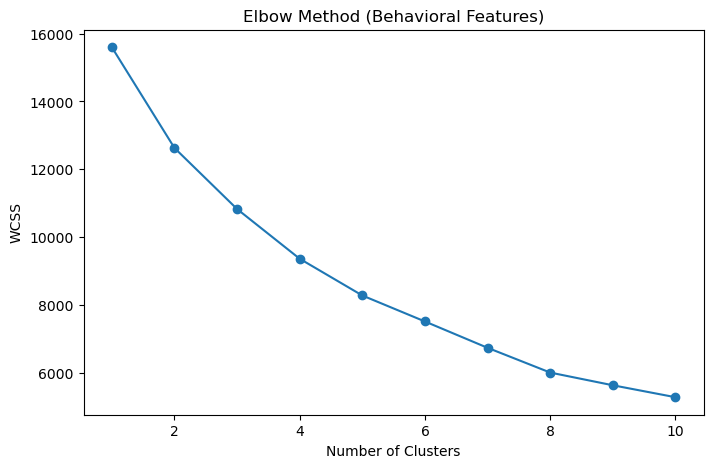

In [28]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method (Behavioral Features)")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

behavior_clusters = kmeans.fit_predict(scaled_features)

In [30]:
df["Behavior_Cluster"] = behavior_clusters

In [31]:
df["Behavior_Cluster"].value_counts()

Behavior_Cluster
1    1033
2     968
3     966
0     933
Name: count, dtype: int64

In [32]:
df.groupby("Behavior_Cluster")[[
    "Age",
    "Purchase Amount (USD)",
    "Previous Purchases",
    "Review Rating"
]].agg(["mean","min","max"])


Age         Purchase Amount (USD)           \
                       mean min max                  mean min  max   
Behavior_Cluster                                                     
0                 31.064309  18  53             61.321543  20  100   
1                 32.407551  18  58             58.385286  20  100   
2                 56.709711  32  70             81.598140  49  100   
3                 56.430642  30  70             37.856108  20   72   

                 Previous Purchases         Review Rating            
                               mean min max          mean  min  max  
Behavior_Cluster                                                     
0                         38.572347  22  50      3.829153  2.5  5.0  
1                         11.154889   1  26      3.732914  2.5  5.0  
2                         25.792355   1  50      3.931715  2.5  5.0  
3                         27.321946   1  50      3.509938  2.5  5.0

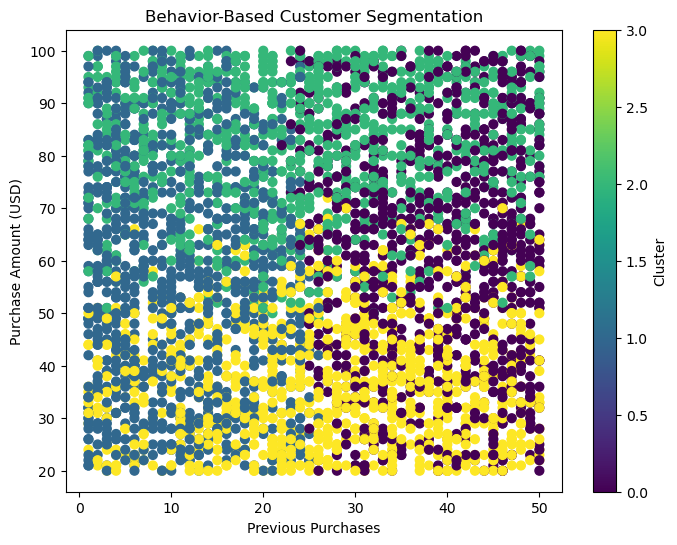

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Previous Purchases"],
    df["Purchase Amount (USD)"],
    c=df["Behavior_Cluster"],
    cmap="viridis",
    s=40
)

plt.xlabel("Previous Purchases")
plt.ylabel("Purchase Amount (USD)")
plt.title("Behavior-Based Customer Segmentation")

plt.colorbar(label="Cluster")

plt.show()


In [34]:
cluster_names = {
    0: "Young Loyal Customers",
    1: "New Customers",
    2: "Premium Senior Customers",
    3: "Budget Senior Customers"
}

df["Customer Segment"] = df["Behavior_Cluster"].map(cluster_names)

df[["Behavior_Cluster","Customer Segment"]].head()

,Behavior_Cluster,Customer Segment
0,3,Budget Senior Customers
1,1,New Customers
2,2,Premium Senior Customers
3,0,Young Loyal Customers
4,3,Budget Senior Customers


In [35]:
df["Customer Segment"].value_counts()

Customer Segment
New Customers               1033
Premium Senior Customers     968
Budget Senior Customers      966
Young Loyal Customers        933
Name: count, dtype: int64

In [36]:
segment_summary = df.groupby("Customer Segment")[[
    "Purchase Amount (USD)",
    "Previous Purchases",
    "Review Rating",
    "Age"
]].mean().round(2)

segment_summary

,Purchase Amount (USD),Previous Purchases,Review Rating,Age
Customer Segment,,,,
Budget Senior Customers,37.86,27.32,3.51,56.43
New Customers,58.39,11.15,3.73,32.41
Premium Senior Customers,81.60,25.79,3.93,56.71
Young Loyal Customers,61.32,38.57,3.83,31.06


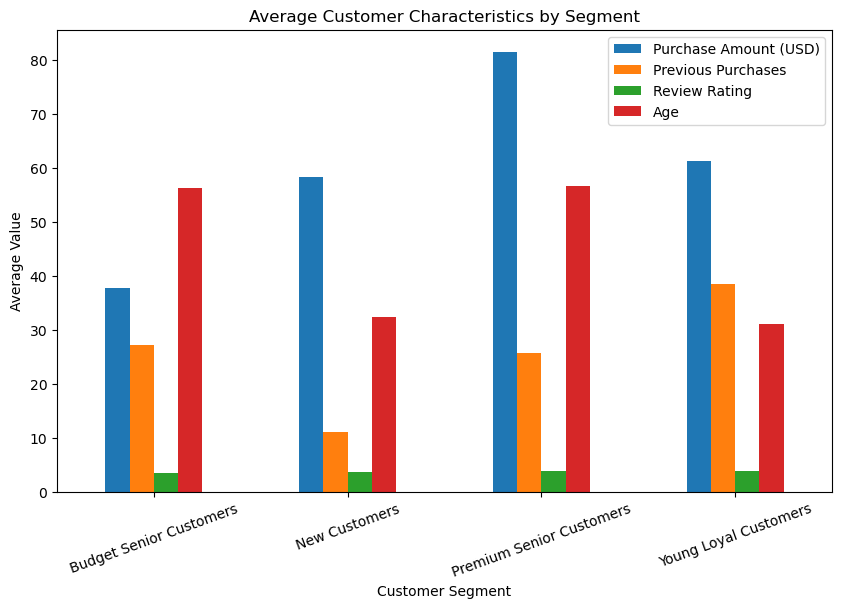

In [37]:
segment_summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Customer Characteristics by Segment")
plt.ylabel("Average Value")
plt.xticks(rotation=20)

plt.show()

In [38]:
df.to_csv("customer_segments.csv", index=False)